In [2]:
# Run this setup only in Google Colab
import os
import subprocess
import sys

try:
    from google.colab import drive
    drive.mount("/content/drive")
    os.chdir("/content/drive/MyDrive/Colab Notebooks/ml2_trabalhos_2026")
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-r", "requirements.txt"])
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-e", ".", "--no-deps"])
except ModuleNotFoundError:
    print("Not running in Colab; skipping Drive mount and install steps.")

Not running in Colab; skipping Drive mount and install steps.


# Trabalho 1 — Classificação de imagens com o Oxford-IIIT Pet

Neste trabalho, você irá treinar e comparar diferentes modelos para classificação de raças no dataset **Oxford-IIIT Pet**.

**Objetivos.**
- construir um pipeline básico de classificação de imagens;
- comparar arquiteturas simples e profundas;
- investigar o efeito de escolhas de treinamento;
- analisar erros e limitações do modelo.

**Entregáveis.**
1. Este notebook preenchido e executado.
2. Os pesos do melhor modelo;
2. Respostas curtas e objetivas nas células de texto.
3. Tabelas e gráficos pedidos ao longo do trabalho.

**Regras gerais.**
- Use **PyTorch**.
- Registre as escolhas principais de hiperparâmetros.
- Quando o enunciado pedir comparação, use evidências dos seus resultados.
- Não apague as células do enunciado.
- Use o conjunto de **teste** apenas na etapa final.



## Parte 0 — Setup e reprodutibilidade

Como treinamos algoritmos que possuem escolhas randômicas, e em máquinas com configurações possivelmente distintas. É importante tentar controlar essas variáveis para garantirmos o máximo de reprodutibilidade dos nossos experimentos.

**Tarefa 0.1**  
Fixe as seeds aleatórias e configure o dispositivo (`cpu` ou `cuda`).

**Tarefa 0.2**  
Imprima as versões de `torch` e `torchvision`, e indique se o notebook está usando CPU ou GPU.

**Tarefa 0.3**  
Crie uma variável `student_run_tag` com uma string curta de sua escolha (por exemplo, suas iniciais e a data).  
Use essa tag ao salvar modelos, figuras e demais artefatos produzidos no notebook.



In [3]:
# TODO: importe as bibliotecas principais
import random
import numpy as np
from pathlib import Path

import torch
import torchvision

# Sugestão: complete com torch.nn, torch.optim, matplotlib etc.
import torch.nn as nn
import torch.optim as optim

import matplotlib.pyplot as plt
from collections import Counter
from tqdm import tqdm

seed = 42
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed_all(seed)
# Adição de generator com a seed setada:
generator = torch.Generator().manual_seed(seed)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Semente: {seed}")
print(f"Dispositivo: {device}")
print("Versão do Torch:", torch.__version__)
print("Versão do Torchvision:", torchvision.__version__)

student_run_tag = "tainaqd"
output_dir = Path("assignment1_outputs")
output_dir.mkdir(exist_ok=True)
(output_dir / student_run_tag).mkdir(exist_ok=True)
print("Diretório de saída:", output_dir / student_run_tag)

Semente: 42
Dispositivo: cuda
Versão do Torch: 2.11.0+cu130
Versão do Torchvision: 0.26.0+cu130
Diretório de saída: assignment1_outputs/tainaqd


## 1. Carregar dados e fazer split

Use o dataset **Oxford-IIIT Pet** do `torchvision`.

**Tarefas**
1. Baixe/carregue o dataset.
2. Separe os dados em **treino**, **validação** e **teste**.
3. Explique brevemente qual split você usou.
4. Mostre o número de exemplos em cada parte.

**Observação.**
- Você pode usar o split oficial de treino/teste e separar parte do treino para validação.
- Para a maior parte do trabalho, use inicialmente transformações simples.


In [4]:
# TODO:
# - importar OxfordIIITPet
# - definir transformações iniciais
# - carregar conjuntos
# - criar split treino/validação
# - criar DataLoaders

# Estrutura sugerida:
from torchvision.datasets import OxfordIIITPet
from torchvision import transforms
from torch.utils.data import DataLoader, random_split

image_size = 224
batch_size = 64

# Escreva seu código aqui
transform = transforms.ToTensor()

In [5]:
# Download do dataset separado para treino/validação e teste
trainval_dataset = OxfordIIITPet(root="./data", split="trainval", transform=transform, download=True)
test_dataset = OxfordIIITPet(root="./data", split="test", transform=transform, download=True)

In [6]:
# Separação de treino e validação
val_size = int(0.2 * len(trainval_dataset))
train_size = len(trainval_dataset) - val_size

train_dataset, val_dataset = random_split(trainval_dataset, [train_size, val_size], generator=generator)

In [7]:
# Criação dos DataLoaders
train_loader = DataLoader(dataset=train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(dataset=val_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(dataset=test_dataset, batch_size=batch_size, shuffle=False)

### Resposta 1.3

Explique brevemente como você construiu o split de treino, validação e teste.


## 2. Visualizar dados e inspecionar balanceamento

Antes de treinar, inspecione o dataset.

**Tarefas**
1. Mostre algumas imagens com seus rótulos.
2. Conte quantos exemplos há por classe no conjunto de treino.
3. Faça um gráfico simples da distribuição por classe.
4. Comente se o conjunto parece balanceado ou não.
5. Aponte ao menos uma dificuldade visual do problema.

In [8]:
# TODO:
# - mostrar algumas imagens do treino
# - obter nomes/classes
# - contar frequência por classe
# - fazer um gráfico simples

# Escreva seu código aqui
# Análise do formato dos dados
breed_names = train_dataset.dataset.classes
print(f"Número de classes: {len(breed_names)}")

print("\nCinco primeiros dados de treino:")
print(f"img format | breed id | breed name")
for i in range(5):
    image, label = train_dataset[i]
    print(image.shape, label, breed_names[label])


Número de classes: 37

Cinco primeiros dados de treino:
img format | breed id | breed name
torch.Size([3, 375, 500]) 19 Leonberger
torch.Size([3, 352, 400]) 0 Abyssinian
torch.Size([3, 500, 375]) 14 German Shorthaired
torch.Size([3, 375, 500]) 27 Russian Blue
torch.Size([3, 375, 500]) 4 Beagle


Exemplos de imagens de treino:


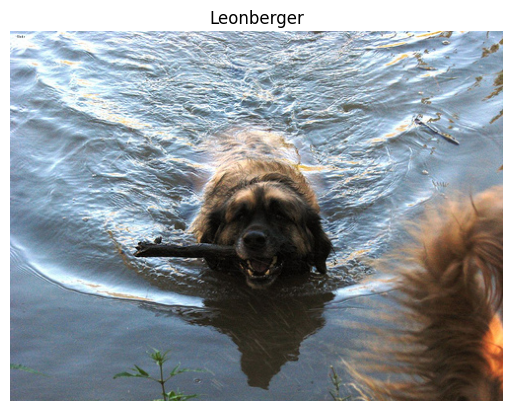

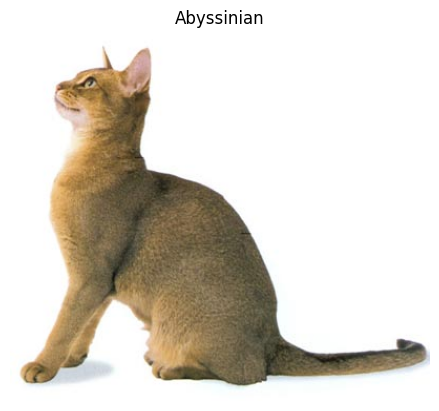

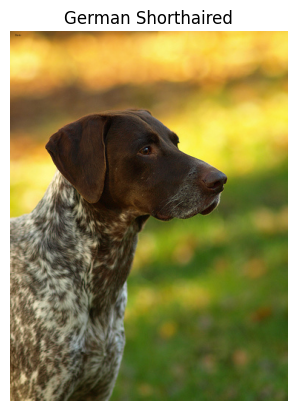

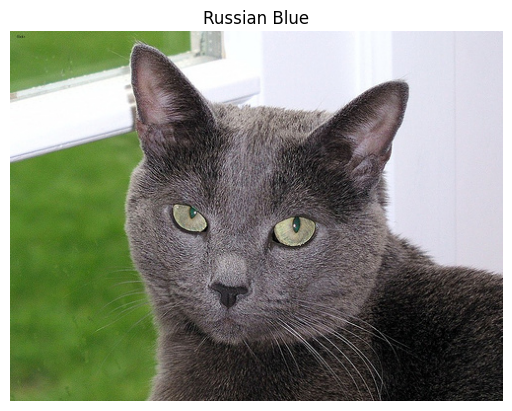

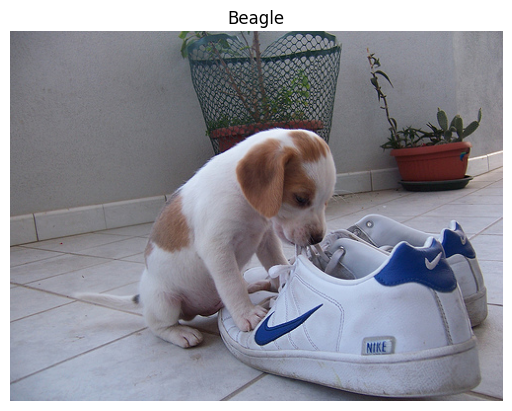

In [9]:
# Visualização de imagens
print("Exemplos de imagens de treino:")
for i in range(5):
    image, label = train_dataset[i]
    plt.imshow(image.permute(1, 2, 0))
    plt.title(breed_names[label])
    plt.axis("off")
    plt.show()

In [10]:
# Distribuição das classes em treino
labels = np.array([train_dataset[i][1] for i in range(len(train_dataset))])
unique, counts = np.unique(labels, return_counts=True)

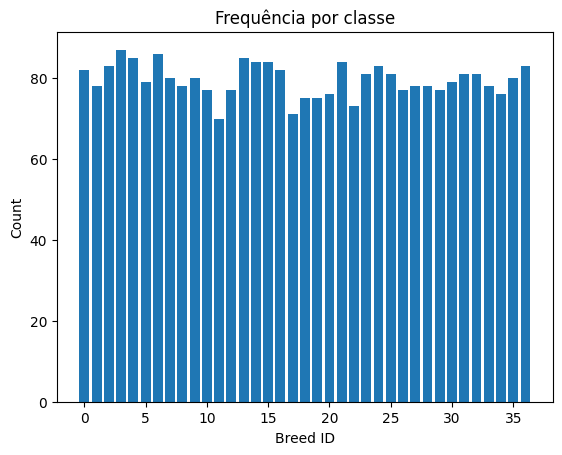

In [11]:
plt.bar(unique, counts)
plt.xlabel("Breed ID")
plt.ylabel("Count")
plt.title("Frequência por classe")
plt.show()

Como as imagens têm dimensões diferentes, precisamos redimensioná-las para um padrão comum.

In [12]:
transform_resize = transforms.Compose([
                    transforms.Resize((224, 224)),
                    transforms.ToTensor()
                ])

trainval_dataset = OxfordIIITPet(root="./data", split="trainval", transform=transform_resize, download=True)
test_dataset = OxfordIIITPet(root="./data", split="test", transform=transform_resize, download=True)

val_size = int(0.2 * len(trainval_dataset))
train_size = len(trainval_dataset) - val_size

train_dataset, val_dataset = random_split(trainval_dataset, [train_size, val_size], generator=generator)

train_loader = DataLoader(dataset=train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(dataset=val_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(dataset=test_dataset, batch_size=batch_size, shuffle=False)

### Resposta 2.4–2.5

Com base nas visualizações e na distribuição por classe, descreva brevemente o que você observou.


## 3. Construa uma FNN simples

Agora construa um primeiro modelo totalmente conectado (**FNN**).

**Tarefas**
1. Defina uma arquitetura simples em PyTorch.
2. Sua FNN deve receber a imagem achatada.
3. Escolha dimensões ocultas razoáveis.
4. Informe o número de parâmetros do modelo.

**Observação.**
Este modelo serve como baseline simples. Não é esperado que funcione bem.


In [13]:
# TODO:
# - definir uma classe FNN(nn.Module)
# - achatar a entrada
# - retornar logits para o número de classes
# - criar uma instância do modelo

# Dica:
# class SimpleFNN(nn.Module):
#     ...

# Escreva seu código aqui
class SimpleFNN(nn.Module):
    def __init__(self, layer_sizes: list[int]):
        super().__init__()
        
        layers = []
        
        for i in range(len(layer_sizes) - 1):
            layers.append(
                nn.Linear(layer_sizes[i], layer_sizes[i+1])
            )
            if i != len(layer_sizes) - 2:
                layers.append(nn.ReLU())
                
        self.network = nn.Sequential(*layers)
    
    def forward(self, x):
        out = x.reshape(x.size(0), -1)
        out = self.network(out)
            
        return out

## 4. Crie funções de treino e avaliação

Implemente funções reutilizáveis para os próximos experimentos.

**Tarefas**
1. Crie uma função `train_one_epoch`.
2. Crie uma função `evaluate`.
3. Crie uma função `fit` que registre métricas por época.
4. Sua avaliação deve retornar pelo menos:
   - loss média
   - acurácia

**Importante.**
Essas funções serão reutilizadas em várias partes do trabalho.


In [ ]:
# TODO:
# - implementar train_one_epoch
# - implementar evaluate
# - implementar fit
# - opcional: salvar histórico em dicionário

# Assinaturas sugeridas:
# def train_one_epoch(model, loader, optimizer, criterion, device):
#     ...
#
# @torch.no_grad()
# def evaluate(model, loader, criterion, device):
#     ...
#
# def fit(model, train_loader, val_loader, optimizer, criterion, device, epochs, scheduler=None):
#     ...

# Escreva seu código aqui

def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    running_loss = 0.0
    
    for images, labels in loader:
        images = images.to(device)
        labels = labels.to(device)
        
        outputs = model(images)
        loss = criterion(outputs, labels)
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()
    
    epoch_loss = running_loss / len(loader)
    
    return epoch_loss
        
@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    correct = 0
    total = 0
    
    for images, labels in loader:
        images = images.to(device)
        labels = labels.to(device)
        
        outputs = model(images)
        preds = outputs.argmax(dim=1)

        total += labels.size(0)
        correct += (preds == labels).sum().item()
        
    return 100 * correct / total

def fit(model, train_loader, val_loader, optimizer, criterion, device, epochs, scheduler=None, verbose=True):
    train_loss = []
    train_accuracies = []
    val_accuracies = []
    
    pbar = tqdm(range(epochs))
    for i in pbar:
        epoch_loss = train_one_epoch(model, train_loader, optimizer, criterion, device)
        train_loss.append(epoch_loss)
        
        train_accuracy = evaluate(model, train_loader, criterion, device)
        train_accuracies.append(train_accuracy)
        val_accuracy = evaluate(model, val_loader, criterion, device)
        val_accuracies.append(val_accuracy)
        
        print(
            f"Acurácia em treino: {train_accuracy}, "
            f"Acurácia em validação: {val_accuracy}"
        )
    
    return train_loss, train_accuracies, val_accuracies

## 5. Treine e avalie a FNN

Use as funções anteriores para treinar sua FNN.

**Tarefas**
1. Escolha uma loss apropriada.
2. Escolha um otimizador.
3. Treine por algumas épocas.
4. Mostre curvas de treino/validação.
5. Reporte as métricas finais em validação.
6. Faça um comentário curto sobre o desempenho da FNN.

**Sugestão.**
Registre as escolhas de hiperparâmetros em uma célula ou tabela.


In [21]:
# TODO:
# - definir criterion e optimizer
# - treinar a FNN
# - guardar histórico
# - plotar curvas
# - reportar métricas finais

# Escreva seu código aqui

layer_sizes = [3*224*224, 1024, 512, 256, 128, 37]

model = SimpleFNN(layer_sizes=layer_sizes).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters())

In [22]:
train_loss, train_accuracies, val_accuracies = fit(model, train_loader, val_loader, optimizer, criterion, device, epochs=100)

  0%|          | 0/100 [00:00<?, ?it/s]

  1%|          | 1/100 [02:39<4:22:41, 159.20s/it]

Acurácia em treino: 3.6005434782608696, Acurácia em teste: 2.4456521739130435


  2%|▏         | 2/100 [05:05<4:07:35, 151.59s/it]

Acurácia em treino: 4.891304347826087, Acurácia em teste: 3.125


...

Acurácia em treino: 10.869565217391305, Acurácia em teste: 6.929347826086956


 15%|█▌        | 15/100 [47:32<4:37:42, 196.03s/it]

Acurácia em treino: 13.485054347826088, Acurácia em teste: 7.201086956521739


 15%|█▌        | 15/100 [57:18<5:24:42, 229.21s/it]


AcceleratorError: CUDA error: unknown error
Search for `cudaErrorUnknown' in https://docs.nvidia.com/cuda/cuda-runtime-api/group__CUDART__TYPES.html for more information.
CUDA kernel errors might be asynchronously reported at some other API call, so the stacktrace below might be incorrect.
For debugging consider passing CUDA_LAUNCH_BLOCKING=1
Compile with `TORCH_USE_CUDA_DSA` to enable device-side assertions.


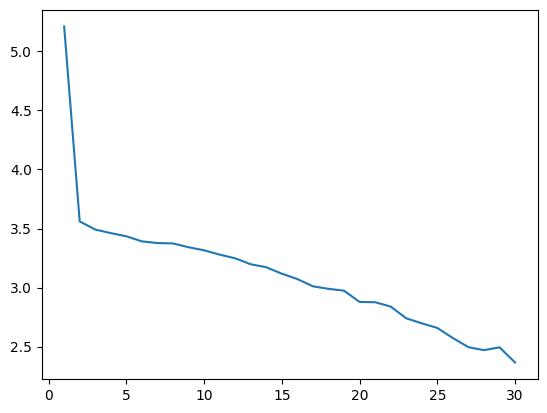

In [20]:
plt.plot(range(1, 31), train_loss)
plt.show()

In [62]:
# 1. Delete model and other tensors
del model
del optimizer
# del tensor_name

# 2. Trigger Python garbage collection
gc.collect()

# 3. Clear the CUDA cache
torch.cuda.empty_cache()

### Resposta 5.6

Comente brevemente o desempenho da FNN. Ela parece adequada para esse problema? Por quê?


## 6. Construa uma CNN simples e compare com a FNN

Agora implemente uma CNN simples.

**Tarefas**
1. Defina uma CNN com algumas camadas convolucionais.
2. Treine e avalie a CNN usando o mesmo protocolo da FNN.
3. Compare FNN e CNN em termos de:
   - acurácia;
   - comportamento das curvas;
   - número de parâmetros.

**Observação.**
A comparação deve ser baseada nos seus resultados.


In [ ]:
# TODO:
# - definir uma CNN simples
# - treinar
# - avaliar
# - comparar com a FNN

# Dica:
# class SimpleCNN(nn.Module):
#     ...

# Escreva seu código aqui

class SimpleCNN(nn.Module):
    def __init__(self):
        super().__init__()
        
        self.network = nn.Sequential(
            nn.Conv2d(in_channels=3, out_channels=32, kernel_size=3, stride=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),
            
            nn.Conv2d(in_channels=32, out_channels=16, kernel_size=3, stride=2),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=1),
            
            nn.Conv2d(in_channels=16, out_channels=8, kernel_size=3, stride=2),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),
            
            nn.Flatten(),
            
            nn.Linear(8 * 53 * 53, 512),
            nn.ReLU(),
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Linear(128, 37)
        )
    
    def forward(self, x):
        out = self.network(x)
        
        return out


### Resposta 6.3

Compare FNN e CNN de forma objetiva. O que mudou? O resultado era esperado?


## 7. Faça pelo menos 3 modificações no treinamento

A partir da sua CNN simples, escolha **pelo menos 3** modificações da lista abaixo:

- Dara Augmentation;
- outro otimizador;
- learning rate scheduler;
- batch normalization;
- dropout;
- CNN mais profunda;
- weight decay regularizer.

**Tarefas**
1. Escolha no mínimo 3 modificações.
2. Execute experimentos controlados.
3. Organize os resultados em uma tabela.
4. Indique claramente qual configuração foi a melhor.

**Importante.**
Tente mudar uma coisa por vez sempre que possível.


In [16]:
# TODO:
# - definir ao menos 3 experimentos
# - treinar cada configuração
# - registrar resultados em uma tabela final


### Resposta 7.4

Liste as modificações escolhidas e justifique em 1–2 linhas por que você decidiu testá-las.


## 8. Analise e discuta o efeito das mudanças

Com base nos experimentos da parte anterior:

**Tarefas**
1. Discuta quais mudanças ajudaram mais.
2. Discuta quais mudanças pouco ajudaram ou pioraram o resultado.
3. Comente possíveis razões para o comportamento observado.
4. Indique qual modelo/configuração você levará para a etapa final.

Use evidências das métricas e curvas.


### Resposta 8

Escreva sua análise aqui.


## 9. Treine usando uma ResNet pré-treinada

Agora use **transfer learning** com uma **ResNet pré-treinada**.

**Tarefas**
1. Carregue uma ResNet pré-treinada do `torchvision`.
2. Adapte a última camada para o número de classes.
3. Treine ao menos uma versão usando transfer learning.
4. Compare com sua melhor CNN da Parte 7.

**Sugestão.**
Você pode começar congelando a maior parte da rede e depois testar fine-tuning.


In [17]:
# TODO:
# - carregar uma ResNet pré-treinada
# - adaptar a camada final
# - treinar
# - avaliar e comparar

# Dica:
# from torchvision.models import resnet18, ResNet18_Weights

# Escreva seu código aqui


### Resposta 9.4

Compare a ResNet com sua melhor CNN anterior. O ganho compensou?


## 10. Avaliações finais

Escolha seu melhor modelo final e faça uma avaliação mais detalhada.

**Tarefas**
1. Avalie no conjunto de teste.
2. Reporte:
   - loss;
   - acurácia;
   - matriz de confusão.
3. Mostre algumas imagens classificadas incorretamente.
4. Identifique pares de classes que geram mais confusão.
5. Discuta brevemente os principais erros do modelo.

**Observação.**
Use esta parte para mostrar que você inspecionou o comportamento do modelo além da acurácia final.


In [18]:
# TODO:
# - avaliar no teste
# - calcular matriz de confusão
# - mostrar erros
# - discutir pares confusos

# Sugestão:
# use sklearn.metrics.confusion_matrix ou implementação própria

# Escreva seu código aqui


### Resposta 10.5

Discuta os erros mais importantes observados na avaliação final.


## 11. Bônus — Robustez

Faça um teste simples de robustez com o seu melhor modelo.

**Exemplos de variações possíveis**
- reduzir a resolução da imagem;
- adicionar ruído leve;
- mudar brilho/contraste;
- aplicar blur leve;
- testar imagens com crop diferente.

**Tarefas**
1. Escolha uma perturbação simples.
2. Compare o desempenho antes e depois.
3. Mostre alguns exemplos.
4. Comente o que isso sugere sobre a robustez do modelo.


In [19]:
# TODO:
# - definir uma perturbação simples
# - reavaliar o melhor modelo
# - comparar métricas
# - mostrar exemplos

# Escreva seu código aqui

## Critérios de avaliação

A correção levará em conta:
- **implementação correta** dos componentes pedidos;
- **qualidade experimental** das comparações;
- **clareza da análise** dos resultados;
- **organização** do notebook;
- **coerência** entre conclusões e evidências.
